In [2]:
from google.colab import files
uploaded = files.upload()

Saving README.md to README.md
Saving ravenstack_support_tickets.csv to ravenstack_support_tickets.csv
Saving ravenstack_subscriptions.csv to ravenstack_subscriptions.csv
Saving ravenstack_feature_usage.csv to ravenstack_feature_usage.csv
Saving ravenstack_churn_events.csv to ravenstack_churn_events.csv
Saving ravenstack_accounts.csv to ravenstack_accounts.csv


In [5]:
import pandas as pd

accounts = pd.read_csv('ravenstack_accounts.csv')
subscriptions = pd.read_csv('ravenstack_subscriptions.csv')
churn = pd.read_csv('ravenstack_churn_events.csv')
support = pd.read_csv('ravenstack_support_tickets.csv')
usage = pd.read_csv('ravenstack_feature_usage.csv')

In [6]:
accounts.head()
subscriptions.head()
churn.head()
usage.head()
support.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [8]:
df = accounts.merge(subscriptions, on='account_id', how='left') \
             .merge(churn, on='account_id', how='left') \
             .merge(usage, on='subscription_id', how='left') \
             .merge(support, on='account_id', how='left')

In [13]:
date_cols = ['join_date', 'subscription_start', 'churn_date', 'signup_date']

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [10]:
df['churn'] = df['churn_date'].notna().astype(int)

In [15]:
df['lifetime_days'] = (df['churn_date'].fillna(pd.Timestamp.today()) - df['signup_date']).dt.days

In [16]:
retention_rate = (df['churn'] == 0).mean()
print("Retention Rate:", retention_rate)

Retention Rate: 0.20177016281711474


In [17]:
churn_rate = df['churn'].mean()
print("Churn Rate:", churn_rate)

Churn Rate: 0.7982298371828853


In [19]:
df['cohort'] = df['signup_date'].dt.to_period('M')

In [22]:
usage['usage_date'] = pd.to_datetime(usage['usage_date'])

temp_subscription_info = subscriptions[['subscription_id', 'account_id']].drop_duplicates()
usage = usage.merge(temp_subscription_info, on='subscription_id', how='left')

account_cohort_map = df[['account_id', 'cohort']].drop_duplicates().set_index('account_id')['cohort']
usage['cohort'] = usage['account_id'].map(account_cohort_map)

usage['usage_month'] = usage['usage_date'].dt.to_period('M')

In [24]:
cohort_data = usage.groupby(['cohort', 'usage_month'])['account_id'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='cohort', columns='usage_month', values='account_id')

In [27]:
if 'plan_tier' not in df.columns:
    df = df.merge(subscriptions[['account_id', 'plan_tier']].drop_duplicates(),
                  on='account_id',
                  how='left')

df.groupby('plan_tier')['churn'].mean().sort_values()

,churn
plan_tier,
Pro,0.794318
Enterprise,0.796391
Basic,0.798594


In [30]:
support_count = support.groupby('account_id').size().reset_index(name='tickets')

df = df.merge(support_count, on='account_id', how='left')
df['tickets'] = df['tickets'].fillna(0)

df.groupby('tickets')['churn'].mean()

,churn
tickets,
0.0,0.683851
1.0,0.722535
2.0,0.826592
3.0,0.829960
4.0,0.810308
5.0,0.832431
6.0,0.807183
7.0,0.574259
8.0,0.824721


In [31]:
usage_count = usage.groupby('account_id').size().reset_index(name='usage_events')

df = df.merge(usage_count, on='account_id', how='left')
df['usage_events'] = df['usage_events'].fillna(0)

df.groupby(pd.qcut(df['usage_events'], 4))['churn'].mean()

/tmp/ipykernel_3086/2431558862.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['usage_events'], 4))['churn'].mean()


,churn
usage_events,
"(9.999, 45.0]",0.779529
"(45.0, 55.0]",0.814886
"(55.0, 66.0]",0.730391
"(66.0, 101.0]",0.863648


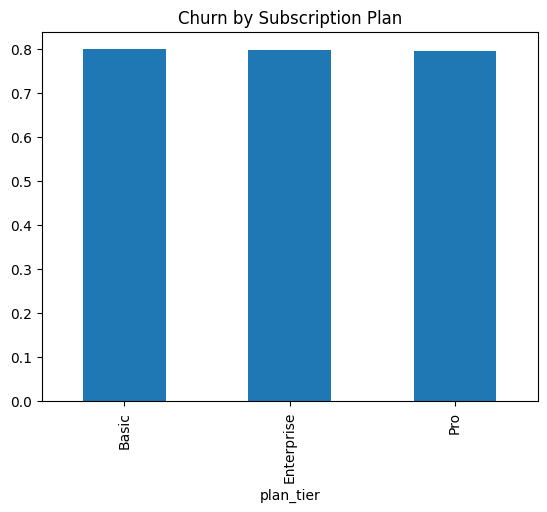

In [33]:
import matplotlib.pyplot as plt

df.groupby('plan_tier')['churn'].mean().plot(kind='bar')
plt.title("Churn by Subscription Plan")
plt.show()

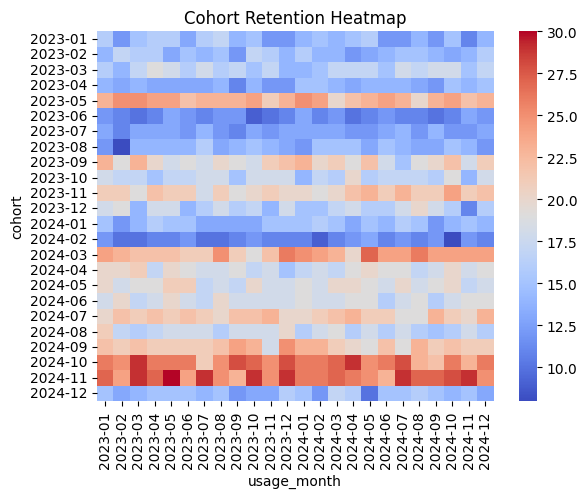

In [34]:
import seaborn as sns

sns.heatmap(cohort_pivot, cmap='coolwarm')
plt.title("Cohort Retention Heatmap")
plt.show()

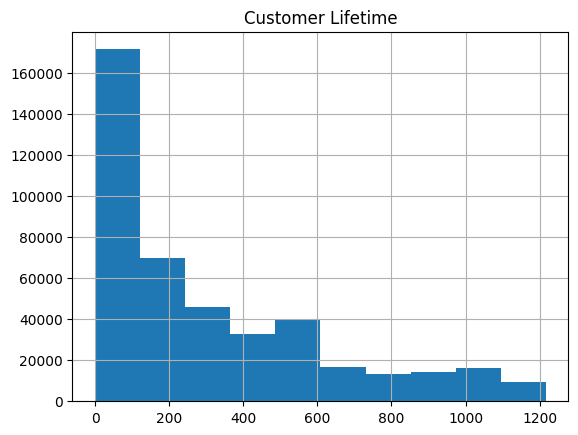

In [35]:
df['lifetime_days'].hist()
plt.title("Customer Lifetime")
plt.show()